Dataset shape: (1080, 19)


,date,region,resource_type,usage_cpu,usage_storage,users_active,economic_index,cloud_market_demand,holiday,cpu_utilization,storage_efficiency,month,day_of_week,is_weekend,quarter,cpu_lag_1,cpu_lag_7,cpu_rolling_7,cpu_rolling_30
0,2023-01-01,East US,VM,88,1959,470,104.97,0.99,1,0.888889,0.981955,1,6,1,1,88.0,88.0,88.000000,88.000000
11,2023-01-01,West US,Container,52,1832,457,104.97,0.99,1,0.525253,0.918296,1,6,1,1,92.0,51.0,73.428571,74.916667
10,2023-01-01,East US,Storage,92,1595,388,104.97,0.99,1,0.929293,0.799499,1,6,1,1,70.0,93.0,73.285714,77.000000
9,2023-01-01,East US,Container,70,621,414,104.97,0.99,1,0.707071,0.311278,1,6,1,1,60.0,76.0,73.428571,75.500000
7,2023-01-01,West US,Storage,85,1371,351,104.97,0.99,1,0.858586,0.687218,1,6,1,1,82.0,88.0,76.714286,78.125000


✅ RandomForest trained
⚠️ Skipping XGBoost (not installed)
✅ ARIMA trained

📊 Model Comparison
RandomForest: MAE=0.00, RMSE=0.00, Bias=-0.00
ARIMA: MAE=12.85, RMSE=14.87, Bias=0.92

🔄 Backtesting RandomForest...


c:\Users\kbhuk\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\kbhuk\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\kbhuk\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\kbhuk\AppData\Local\Programs\Python\Python312\Lib

             MAE       RMSE       Bias
count  46.000000  46.000000  46.000000
mean    0.000233   0.000516  -0.000109
std     0.000584   0.001181   0.000542
min     0.000000   0.000000  -0.002857
25%     0.000000   0.000000   0.000000
50%     0.000000   0.000000   0.000000
75%     0.000000   0.000000   0.000000
max     0.002857   0.005345   0.000714


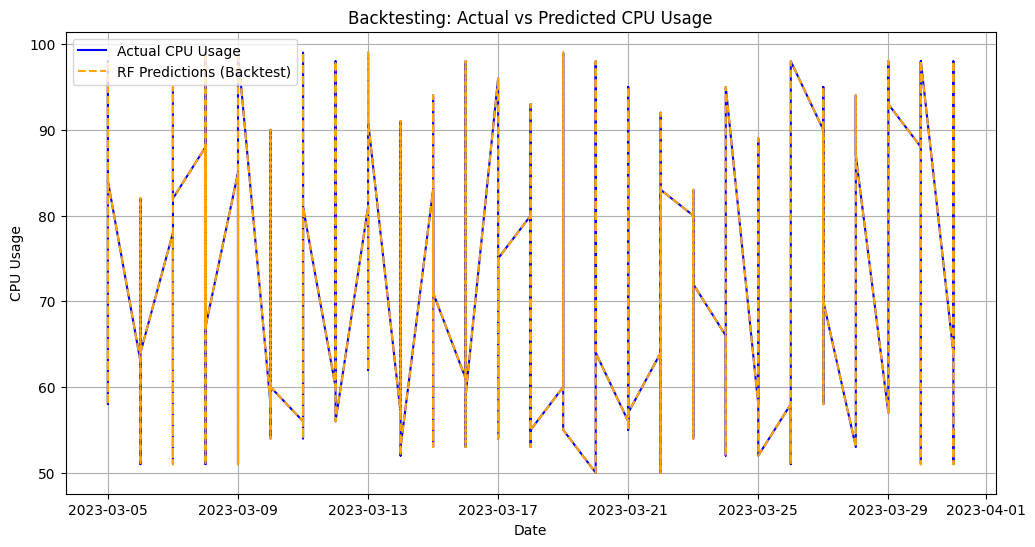


✅ Best model selected: RandomForest
✅ Model saved to: c:\Users\kbhuk\OneDrive\Desktop\azure-demand-forecasting\backend\models\cpu_forecast.pkl


In [4]:
# ------------------------------
# Milestone 3: Model Development
# ------------------------------

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import matplotlib.pyplot as plt

# Models
from sklearn.ensemble import RandomForestRegressor
try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None

# ARIMA
try:
    from statsmodels.tsa.arima.model import ARIMA
except ImportError:
    ARIMA = None

# ------------------------------
# 1. Load dataset
# ------------------------------
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(".")))
DATA_PATH = os.path.join(BASE_DIR, "backend", "data", "cleaned_merged.csv")
MODEL_PATH = os.path.join(BASE_DIR, "backend", "models", "cpu_forecast.pkl")

df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date")
print("Dataset shape:", df.shape)
display(df.head())

# ------------------------------
# 2. Define target & features
# ------------------------------
target = "usage_cpu"
feature_cols = [
    "cpu_utilization",
    "storage_efficiency",
    "month",
    "day_of_week",
    "is_weekend",
    "cpu_lag_1",
    "cpu_lag_7",
    "cpu_rolling_7",
    "cpu_rolling_30",
    "econ_index",
    "market_trend",
    "holiday_flag"
]

feature_cols = [c for c in feature_cols if c in df.columns]
X = df[feature_cols].fillna(0)
y = df[target].fillna(0)

# Train/test split (time-based)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

results = {}

# ------------------------------
# 3A. RandomForest
# ------------------------------
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

results["RandomForest"] = {
    "MAE": mean_absolute_error(y_test, rf_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, rf_pred)),
    "Bias": (rf_pred - y_test).mean(),
    "model": rf,
}
print("✅ RandomForest trained")

# ------------------------------
# 3B. XGBoost (optional)
# ------------------------------
if XGBRegressor is not None:
    xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict(X_test)

    results["XGBoost"] = {
        "MAE": mean_absolute_error(y_test, xgb_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, xgb_pred)),
        "Bias": (xgb_pred - y_test).mean(),
        "model": xgb,
    }
    print("✅ XGBoost trained")
else:
    print("⚠️ Skipping XGBoost (not installed)")

# ------------------------------
# 3C. ARIMA (optional)
# ------------------------------
if ARIMA is not None:
    try:
        series = df[target].dropna()
        train_size = int(len(series) * 0.8)
        train_series, test_series = series[:train_size], series[train_size:]

        arima = ARIMA(train_series, order=(5,1,0))
        arima_fit = arima.fit()
        arima_pred = arima_fit.forecast(steps=len(test_series))

        results["ARIMA"] = {
            "MAE": mean_absolute_error(test_series, arima_pred),
            "RMSE": np.sqrt(mean_squared_error(test_series, arima_pred)),
            "Bias": (arima_pred - test_series).mean(),
            "model": arima_fit,
        }
        print("✅ ARIMA trained")
    except Exception as e:
        print("⚠️ ARIMA failed:", e)
else:
    print("⚠️ Skipping ARIMA (statsmodels not installed)")

# ------------------------------
# 4. Compare results
# ------------------------------
print("\n📊 Model Comparison")
for model_name, metrics in results.items():
    print(f"{model_name}: MAE={metrics['MAE']:.2f}, RMSE={metrics['RMSE']:.2f}, Bias={metrics['Bias']:.2f}")

# ------------------------------
# 5. Backtesting (Walk-Forward Validation)
# ------------------------------
def backtest(model, df, features, target="usage_cpu", train_size=0.7, step=7):
    """
    Walk-forward validation:
    - Train on initial train_size portion
    - Forecast 'step' days ahead
    - Slide window forward and repeat
    """
    errors = []
    preds_all = []
    actuals_all = []

    n = len(df)
    split_point = int(n * train_size)

    for start in range(split_point, n - step, step):
        train = df.iloc[:start]
        test = df.iloc[start:start+step]

        if len(test) == 0:
            break

        X_train, y_train = train[features], train[target]
        X_test, y_test = test[features], test[target]

        # Re-initialize model
        m = model.__class__(**model.get_params())
        m.fit(X_train, y_train)

        y_pred = m.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        bias = (y_pred - y_test).mean()

        errors.append({"MAE": mae, "RMSE": rmse, "Bias": bias})
        preds_all.extend(y_pred)
        actuals_all.extend(y_test)

    return pd.DataFrame(errors), preds_all, actuals_all

# Run backtesting for RandomForest
print("\n🔄 Backtesting RandomForest...")
rf_errors, rf_preds, rf_actuals = backtest(rf, df, feature_cols)
print(rf_errors.describe())

# Backtesting for XGBoost (if available)
if "XGBoost" in results:
    print("\n🔄 Backtesting XGBoost...")
    xgb_errors, xgb_preds, xgb_actuals = backtest(results["XGBoost"]["model"], df, feature_cols)
    print(xgb_errors.describe())

# ------------------------------
# 6. Visualization: Actual vs Predictions
# ------------------------------
plt.figure(figsize=(12,6))

# Plot actual demand
plt.plot(df["date"][-len(rf_actuals):], rf_actuals, label="Actual CPU Usage", color="blue")

# Plot RF predictions
plt.plot(df["date"][-len(rf_preds):], rf_preds, label="RF Predictions (Backtest)", color="orange", linestyle="--")

# If XGBoost backtest exists, plot it too
if "XGBoost" in results and "xgb_preds" in locals():
    plt.plot(df["date"][-len(xgb_preds):], xgb_preds, label="XGBoost Predictions (Backtest)", color="green", linestyle="--")

plt.title("Backtesting: Actual vs Predicted CPU Usage")
plt.xlabel("Date")
plt.ylabel("CPU Usage")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------
# 7. Select best model
# ------------------------------
best_model_name = min(results, key=lambda m: results[m]["RMSE"])
best_model = results[best_model_name]["model"]

print(f"\n✅ Best model selected: {best_model_name}")

# ------------------------------
# 8. Save final model
# ------------------------------
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
joblib.dump(best_model, MODEL_PATH)
print("✅ Model saved to:", MODEL_PATH)


In [2]:
!pip install scikit-learn

^C


   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   --------------------------- ------------ 6.0/8.7 MB 28.4 MB/s eta 0:00:01
   ---------------------------------------- 8.7/8.7 MB 22.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.6 MB ? eta -:--:--
   ------- -------------------------------- 6.8/38.6 MB 29.9 MB/s eta 0:00:02
   ---------- ----------------------------- 10.5/38.6 MB 24.2 MB/s eta 0:00:02
   -------------- ------------------------- 13.9/38.6 MB 21.3 MB/s eta 0:00:02
   ----------------- ---------------------- 17.3/38.6 MB 20.2 MB/s eta 0:00:02
   ---------------------- ----------------- 21.8/38.6 MB 20.2 MB/s eta 0:00:01
   -------------------------- ------------- 25.7/38.6 MB 20.3 MB/s eta 0:00:01
   ----------------------------- ---------- 28.8/38.6 MB 19.7 MB/s eta 0:00:01
   ------------------------------- -------- 29.9/38.6 MB 18.6 MB/s eta 0:00:01
   -------------------------------- ------- 31.7/38.6 MB 16.6 MB/s eta 0:00:


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
